# 2D Structure Function Data with TERRA SST

This example will guide you through each step necessary to compute scalar-based structure functions from a 2D data of sea surface temperature.

$\textbf{General procedure}:$


    1 -  Load a TERRA dataset generated with https://search.earthdata.nasa.gov
    2 -  Subset and Format dataset
    3 -  Calculate 2D scalar-based SST structure function as a function of separation distances
    4 -  Plot the 2D scalar-based SF with errors and number of bootstraps
    5 -  Plot Isotropic scalar-based SF with isotropy and homogeneity errors


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load the TERRA Dataset

In [2]:
ds = xr.open_dataset('example_data/TERRA_MODIS.20250201_20250228.L3m.MO.NSST.sst.4km.nc')
subset = ds.sel(lon=slice(-75,-45),lat=slice(42.0,12.0))
subset

<xarray.Dataset> Size: 4MB
Dimensions:   (lat: 720, lon: 720, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat       (lat) float32 3kB 41.98 41.94 41.9 41.85 ... 12.1 12.06 12.02
  * lon       (lon) float32 3kB -74.98 -74.94 -74.9 ... -45.1 -45.06 -45.02
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    sst       (lat, lon) float32 2MB ...
    qual_sst  (lat, lon) float32 2MB ...
    palette   (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/60)
    product_name:                     TERRA_MODIS.20250201_20250228.L3m.MO.NS...
    instrument:                       MODIS
    title:                            MODIST Level-3 Standard Mapped Image
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Terra
    source:                           satellite observations from MODIS-Terra
    ...                               ...
    publisher_url:                    https://oceandata.sci.gsfc.nasa.gov
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    data_bins:                        19867739
    data_minimum:                     -1.8
    data_maximum:                     34.556667

# Make A quick Plot

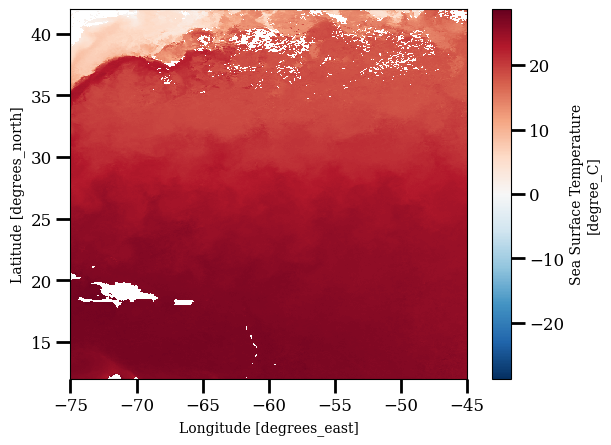

In [3]:
subset.sst[::-1,:].plot()

# Format Dataset

In [4]:
lon_center = np.nanmin(subset.lon)
utm_zone = int(1 + (lon_center + 180.0) / 6.0)
# Create the projection
proj = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', datum='WGS84')

x, y = proj(subset.lon.values, subset.lat.values[::-1]) # order lat values 

Y,X = np.meshgrid(y,x,indexing='ij')
# Create the xarray dataset
ds_new = xr.Dataset({
    'sst': (['y', 'x'], subset.sst.values[::-1,:]), # order sst according to lat values

}, coords={
    'x': (['y', 'x'], X),
    'y': (['y', 'x'], Y)
})

In [5]:
ds_new

<xarray.Dataset> Size: 10MB
Dimensions:  (y: 720, x: 720)
Coordinates:
    x        (y, x) float64 4MB 5.023e+05 5.068e+05 ... 2.989e+06 2.991e+06
    y        (y, x) float64 4MB 1.329e+06 1.329e+06 ... 5.106e+06 5.106e+06
Data variables:
    sst      (y, x) float32 2MB 26.58 26.61 26.55 26.5 ... 17.05 nan nan nan

# Calculate 2D SST SF $\delta T (r_{x},r_{y})$

In [6]:
%%time

bins = {
    'x': np.logspace(np.log10(4534.), np.log10(2.4e6), 11),
    'y': np.logspace(np.log10(4608.), np.log10(3.7e6), 11)
}
sf_result = psf.bin_sf_2d(
    ds=ds_new,
    variables_names=["sst"],
    order=1,
    bins=bins,
    fun='scalar',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0,
    backend='loky'
)

Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8]

STARTING BIN_SF WITH FUNCTION TYPE: scalar
Variables: ['sst'], Order: 1


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 15 bootstraps
Processing spacing 2 with 15 bootstraps
Processing spacing 4 with 15 bootstraps
Processing spacing 8 with 15 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245599
Bins with points: 96/100
Marked 4 bins as converged (low_density)
Marked 67 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 29 unconverged bins
Grouped unconverged bins into 2 groups

Processing 1 bins with step size 40 in density quartile 1

Processing 28 bins with step size 40 in density quartile 0
  Bin (2,6) CONVERGED with std 0.970140
  Bin (6,2) CONVERGED with std 0.989326

Iteration 2 - 27 unconverged bins
Grouped unconverged bins into 2 grou

# Plot 2D SFs

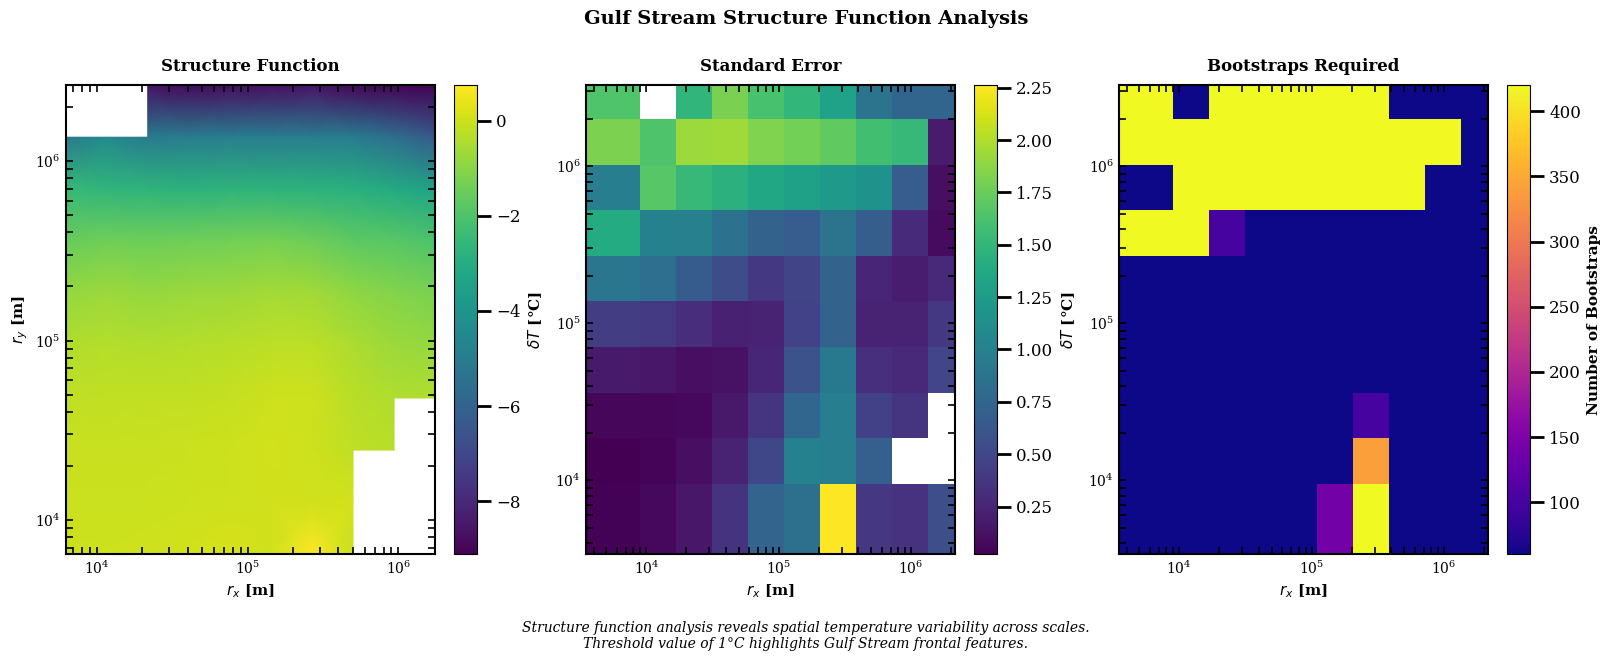

In [7]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

# Common settings for all plots
plot_titles = ['Structure Function', 'Standard Error', 'Bootstraps Required']
cmaps = ['viridis', 'viridis', 'plasma']
labels = [r'$\delta T$ [°C]', r'$\delta T$ [°C]', 'Number of Bootstraps']

# Data to plot
data_to_plot = [sf_result.sf, sf_result.sf_std, sf_result.nbootstraps]

for i, (ax, data, title, cmap, label) in enumerate(zip(axes, data_to_plot, plot_titles, cmaps, labels)):
    # Create the plot with specific shading for the first plot
    if i == 0:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='gouraud')
    else:
        im = ax.pcolormesh(sf_result.x, sf_result.y, data, cmap=cmap, shading='auto')
    
    # Add colorbar with proper formatting
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(label, fontsize=11, fontweight='bold')
    
    # Set axis labels and title
    ax.set_xlabel(r'$r_x$ [m]', fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$r_y$ [m]', fontsize=11, fontweight='bold')
    
    # Set log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Add title
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Customize spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Customize tick parameters
    ax.tick_params(which='both', direction='in', width=1.2, length=5, 
                  labelsize=10, top=True, right=True)
        
    # Add scientific notation for axes
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Add main title for the entire figure
fig.suptitle('Gulf Stream Structure Function Analysis', fontsize=14, fontweight='bold', y=1.08)

# Add annotation explaining the analysis
fig.text(0.5, -0.08, 
         'Structure function analysis reveals spatial temperature variability across scales.\n'
         'Threshold value of 1°C highlights Gulf Stream frontal features.',
         ha='center', fontsize=10, fontstyle='italic')

plt.show()

# Calculate ISOTROPIC SST SF $\delta T(r)$

In [11]:
%%time

bins = {
    'r': np.logspace(np.log10(5000.), np.log10(1000000.0), 15),
}
iso_sf = psf.get_isotropic_sf_2d(
    ds=ds_new,
    variables_names=["sst"],
    order=1,
    bins=bins,
    fun='scalar',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0,
    window_size_r=8,
    window_size_theta=10,
    backend='loky'
)

Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: scalar
Variables: ['sst'], Order: 1


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 15 bootstraps
Processing spacing 2 with 15 bootstraps
Processing spacing 4 with 15 bootstraps
Processing spacing 8 with 15 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245720
Bins with points: 14/14
Marked 11 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 3 unconverged bins
Grouped unconverged bins into 1 groups

Processing 3 bins with step size 40 in density quartile 0
  Bin 10 CONVERGED with std 0.874031

Iteration 2 - 2 unconverged bins
Grouped unconverged bins into 1 groups

Processing 2 bins with step size 40 in density quartile 0

Iteration 3 - 2 unconverged bins
Grouped unconverged bins into 1 groups

Proce

# Plot Isotropic SF

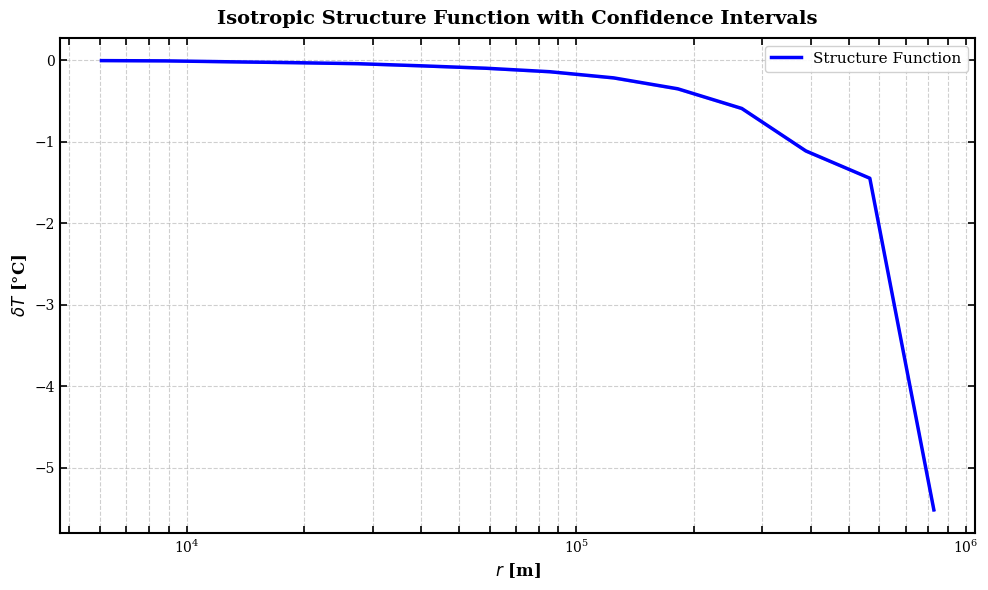

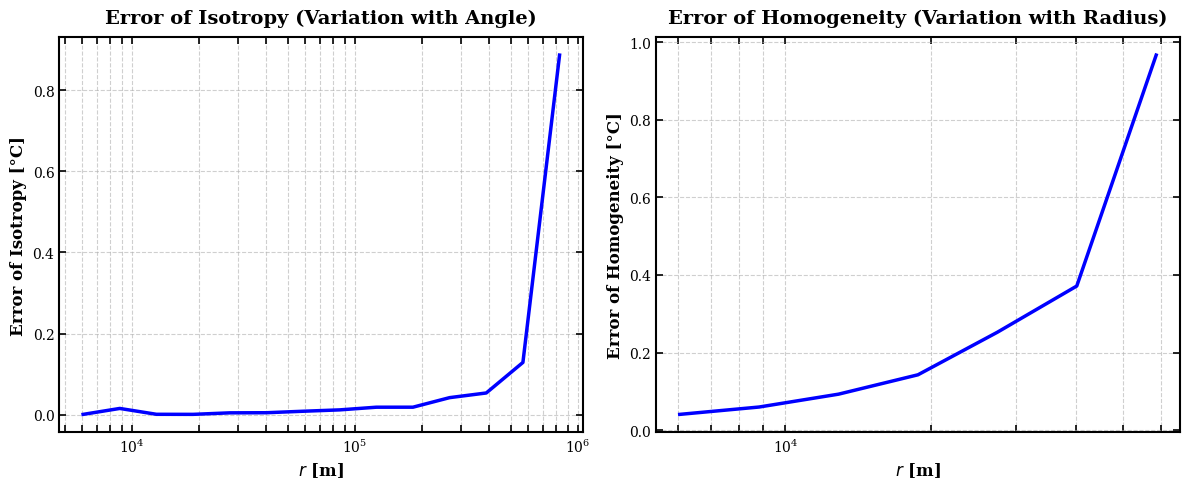

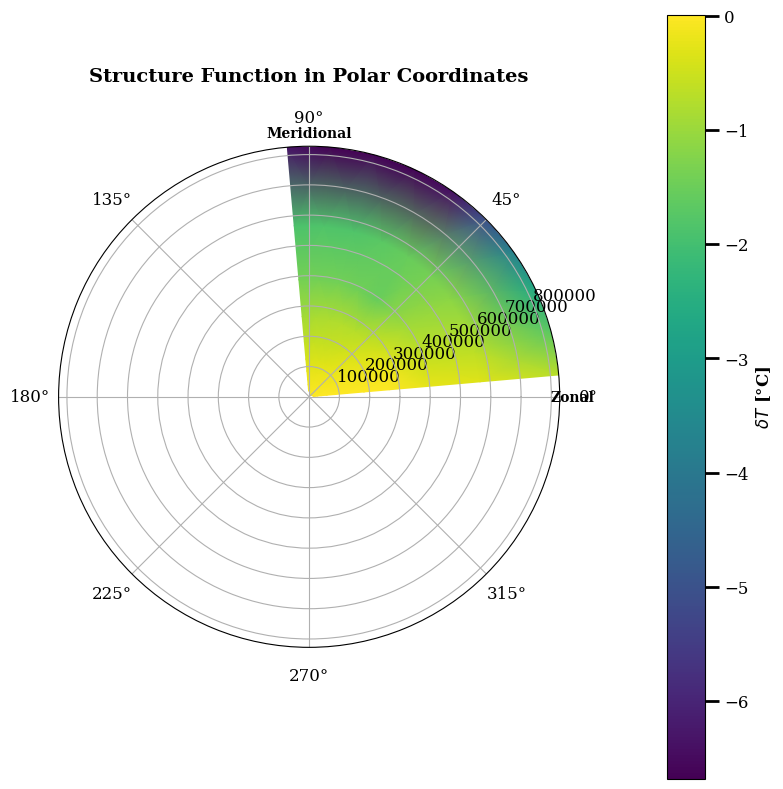

In [12]:
# Create separate figures for better spacing and clarity
plt.figure(figsize=(10, 6))
# Structure Function with Confidence Interval
plt.plot(iso_sf.r, iso_sf.sf, 'b-', linewidth=2.5, label='Structure Function')
plt.fill_between(iso_sf.r, 
                iso_sf.ci_lower, 
                iso_sf.ci_upper, 
                alpha=0.3, color='blue')

# Formatting
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel(r'$\delta T$ [°C]', fontsize=12, fontweight='bold')
plt.title('Isotropic Structure Function with Confidence Intervals', 
         fontsize=14, fontweight='bold', pad=10)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Customize tick parameters
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Errors of Isotropy and Homogeneity
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# Error of isotropy
plt.subplot(121)
plt.plot(iso_sf.r, iso_sf.error_isotropy, 'b-', linewidth=2.5)
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Isotropy [°C]', fontsize=12, fontweight='bold')
plt.title('Error of Isotropy (Variation with Angle)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Error of homogeneity
plt.subplot(122)
plt.plot(iso_sf.r_subset, iso_sf.error_homogeneity, 'b-', linewidth=2.5)
plt.xlabel(r'$r$ [m]', fontsize=12, fontweight='bold')
plt.ylabel('Error of Homogeneity [°C]', fontsize=12, fontweight='bold')
plt.title('Error of Homogeneity (Variation with Radius)', 
         fontsize=14, fontweight='bold', pad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xscale('log')

# Customize spines and ticks
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(which='both', direction='in', width=1.2, length=5, 
              labelsize=10, top=True, right=True)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())

plt.tight_layout()

# --------------------------------------------------
# Polar representation of structure function
# --------------------------------------------------
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Longitudinal structure function
pcm = ax.pcolormesh(iso_sf.theta, iso_sf.r, iso_sf.sf_polar.T, 
                   cmap='viridis', shading='gouraud')
ax.set_title('Structure Function in Polar Coordinates', 
            fontsize=14, fontweight='bold', pad=20)

# Add custom colorbar with proper labeling
cbar = plt.colorbar(pcm, pad=0.15)
cbar.set_label(r'$\delta T$ [°C]', fontsize=12, fontweight='bold')

# Annotate directional features
ax.text(0, ax.get_rmax()*1.05, 'Zonal', 
       ha='center', va='center', fontweight='bold')
ax.text(np.pi/2, ax.get_rmax()*1.05, 'Meridional', 
       ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()